In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from scipy.stats import chi2
import pandas as pd
custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

In [71]:
import rate_exp as re

$$R_{exp} = \mu_{UL}/expousure$$

Primero tenemos que calcular el mu del upper limit que sale de encontrar aquel mu que cumple:

$$0,10 = \sum_{i = 0}^{k_{obs}} P(\mu_{UL}|k_i)$$

Para $k_{obs}$ eventos observados de $n_i$ electrones

In [72]:
eventos = np.array([7,4,0,0,0,0])
expos = np.array([46.61,57.71,63.03,65.56,67.31,68.53])/1000
display(expos)

array([0.04661, 0.05771, 0.06303, 0.06556, 0.06731, 0.06853])

In [73]:
p_on_the_left = 1 - 0.9
degrees_of_freedom = 2 * (eventos + 1)
x = chi2.ppf(1 - p_on_the_left, degrees_of_freedom)
mu_ul = x / 2
print(mu_ul)

[11.77091446  7.99358959  2.30258509  2.30258509  2.30258509  2.30258509]


In [74]:
rates_exp = mu_ul / expos
rates_exp

array([252.54053769, 138.51307548,  36.53157374,  35.12179825,
        34.2086628 ,  33.59966574])

Ahora vamos a suponer que podemos hacer:

$$\varepsilon_{m}^2 = (R_{m}/R_{esp})\cdot \varepsilon_{ref}^2$$

donde: m indica medido, ref indica de referencia y esp es el esperado

In [75]:
df_pb = pd.read_csv('Rates_PB_eps_1e-2_m10-800.csv')
df_md = pd.read_csv('Rates_MD_eps_1e-2_m10-800.csv')


In [76]:
def limites_exclusion(r_exp, df, sigma,ne):
   if ne < 1 or ne > 10:
       raise ValueError("ne debe estar entre 1 y 10")
   if not isinstance(ne, int):
       raise TypeError("ne debe ser un entero")
   if sigma <= 0:
       raise ValueError("La sección eficaz del dataframe debe ser un número positivo")
  
   r_teo = np.array(df[f'{ne}e'])
   sigma_exp = (r_exp/r_teo)*sigma
  
   return sigma_exp  

In [77]:
len(df_pb)

100

In [78]:
eps_pb = np.zeros((len(rates_exp),len(df_pb)))
eps_md = np.zeros((len(rates_exp),len(df_md)))
for i in range(len(rates_exp)):
    eps_pb_ = limites_exclusion(rates_exp[i], df_pb, (1e-2)**2, i+2)
    eps_md_ = limites_exclusion(rates_exp[i], df_md, (1e-2)**2, i+2)
    eps_pb[i, :] = eps_pb_
    eps_md[i, :] = eps_md_

In [79]:
eps_pb[0,:]

array([1.81614196e+10, 1.81569847e+10, 1.82837569e+10, 1.86055448e+10,
       1.86160243e+10, 1.86113381e+10, 1.89844670e+10, 1.94600113e+10,
       1.97641142e+10, 2.00192287e+10, 2.03307982e+10, 2.06794412e+10,
       2.10568969e+10, 2.12786944e+10, 2.14741587e+10, 2.16933098e+10,
       2.20368132e+10, 2.24077053e+10, 2.28025547e+10, 2.31045099e+10,
       2.34288154e+10, 2.37776923e+10, 2.40324169e+10, 2.41699792e+10,
       2.43154680e+10, 2.44694331e+10, 2.46998567e+10, 2.50567553e+10,
       2.54410196e+10, 2.58535496e+10, 2.62323867e+10, 2.66404418e+10,
       2.70807809e+10, 2.75978621e+10, 2.81725194e+10, 2.87993662e+10,
       2.93362971e+10, 2.93294169e+10, 2.93222285e+10, 2.93147181e+10,
       2.93073867e+10, 2.93004295e+10, 2.92931606e+10, 2.92855663e+10,
       2.92785069e+10, 2.92714225e+10, 2.92640208e+10, 2.93166598e+10,
       2.95245080e+10, 2.97449479e+10, 2.99789223e+10, 3.01774586e+10,
       3.03840022e+10, 3.06029483e+10, 3.07468784e+10, 3.07395661e+10,
      

Text(0, 0.5, 'ε²')

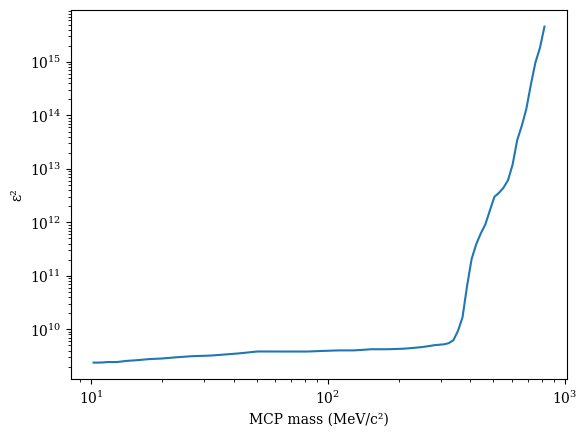

In [80]:
plt.plot(df_pb[df_pb.columns[0]], eps_pb[5,:], label='PB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('MCP mass (MeV/c²)')
plt.ylabel('ε²')